# Hard-to-distinguish biologically related cell-type subtypes

This notebook is the extracted hard-cell-type section from `02_disentangle.ipynb`. It reads canonical full-data benchmark, disentanglement, and single-cell recovery outputs and does not fit or alter any model.

## Setup from canonical outputs

In [1]:
suppressPackageStartupMessages({
  library(here); library(dplyr); library(tidyr); library(ggplot2); library(patchwork)
})

ROOT_OUT <- here('output', '03_model_biology', '02_pseudobulk')
BENCH_DIR <- file.path(ROOT_OUT, '00_benchmark')
DIS_DIR <- file.path(ROOT_OUT, '02_disentangle')
SC_DIR <- file.path(ROOT_OUT, '03_b_matrix_singlecell')
OUT_DIR <- file.path(ROOT_OUT, '04_hard_cell_types')
dir.create(OUT_DIR, recursive = TRUE, showWarnings = FALSE)

top_lvs_df <- read.csv(file.path(DIS_DIR, 'top_lvs_per_celltype.csv'), stringsAsFactors = FALSE)
lv_corr_full <- read.csv(file.path(BENCH_DIR, 'clampfull_lv_ct_corr_full.csv'), stringsAsFactors = FALSE)
selected_all_df <- read.csv(file.path(DIS_DIR, 'module_selected_lvs.csv'), stringsAsFactors = FALSE)
top_pathway_df <- read.csv(file.path(DIS_DIR, 'marker_pathway_recovery.csv'), stringsAsFactors = FALSE)
enr_all <- read.csv(file.path(DIS_DIR, 'marker_enrichment_long.csv'), stringsAsFactors = FALSE)
lv_effect_all <- read.csv(file.path(DIS_DIR, 'lv_marker_effects.csv'), stringsAsFactors = FALSE)
recovery_df <- read.csv(file.path(SC_DIR, 'recovery_summary.csv'), stringsAsFactors = FALSE)

module_results <- lapply(split(selected_all_df, selected_all_df$dataset),
                         function(x) list(selected = x))
Z_LIM <- max(abs(lv_effect_all$row_effect), na.rm = TRUE)
recovered_top_q <- -log10(top_pathway_df$top1_fdr[top_pathway_df$recovered %in% TRUE] + 1e-300)
Q_LIM <- max(c(enr_all$neg_log10_fdr, recovered_top_q), na.rm = TRUE)

ct_labels_df <- read.csv(here('data', 'pseudobulk', 'cell_type_labels.csv'),
                         stringsAsFactors = FALSE)
CT_LABELS <- setNames(ct_labels_df$label, ct_labels_df$cell_type)
ct_label <- function(x) ifelse(x %in% names(CT_LABELS), CT_LABELS[x], x)

## Hard to distinguish biologically related cell-type subtypes

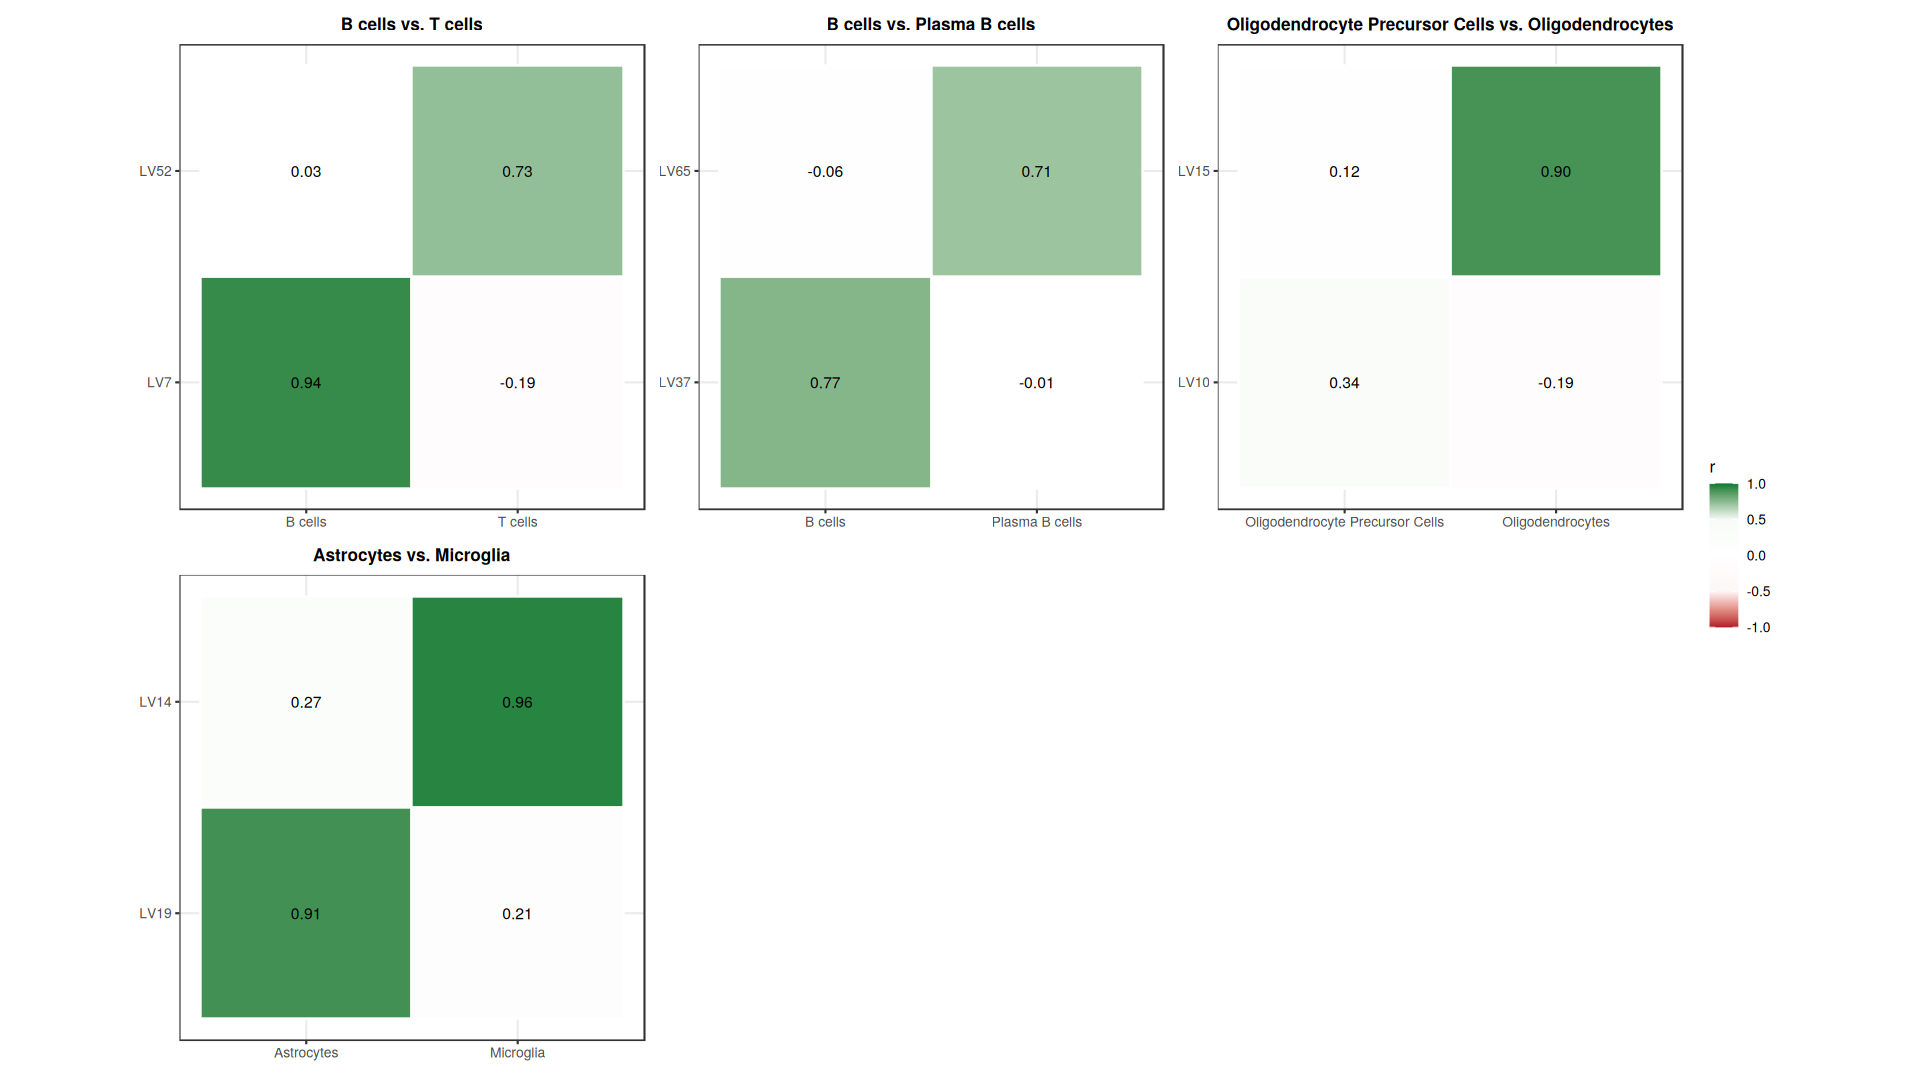

In [2]:
# Biologically related cell-type subtypes, checked per dataset
RELATED_GROUPS <- list(
    list(ds = "PBMC_Perez2022",  cts = c("B_cell", "T_cell")),
    list(ds = "PBMC_1k1k",        cts = c("B_cell", "Plasma_B")),
    list(ds = "Brain_Xiong2023",  cts = c("Opc", "Oli")),
    list(ds = "Brain_Mathys2023", cts = c("Ast", "Mic"))
)

group_panels <- lapply(RELATED_GROUPS, function(grp) {
    ds        <- grp$ds
    ds_assign <- top_lvs_df[top_lvs_df$dataset == ds, ]
    cts       <- intersect(grp$cts, ds_assign$cell_type)
    if (length(cts) < 2) return(NULL)

    lvs <- ds_assign$LV[match(cts, ds_assign$cell_type)]
    sub <- lv_corr_full[lv_corr_full$dataset == ds & lv_corr_full$LV %in% lvs &
                         lv_corr_full$cell_type %in% cts, ]
    sub$cell_type_label <- factor(ct_label(sub$cell_type), levels = ct_label(cts))
    sub$LV              <- factor(sub$LV, levels = lvs)

    ggplot(sub, aes(x = cell_type_label, y = LV, fill = cor)) +
        geom_tile(color = "white", linewidth = 0.5) +
        geom_text(aes(label = sprintf("%.2f", cor)), size = 3.2) +
        # Match the full correlation heatmaps: weak correlations stay near white.
        scale_fill_gradientn(colours = c("#b2182b", "#fdf7f7", "white", "#f7fbf7", "#007a33"),
                             values = scales::rescale(c(-1, -0.5, 0, 0.5, 1)),
                             limits = c(-1, 1), name = "r") +
        coord_fixed() +
        theme_bw(base_size = 10) +
        theme(plot.title = element_text(face = "bold", size = 10, hjust = 0.5)) +
        labs(x = NULL, y = NULL,
             title = paste(ct_label(cts), collapse = " vs. "))
})
group_panels <- Filter(Negate(is.null), group_panels)

options(repr.plot.width = 16, repr.plot.height = 9)
p_groups <- wrap_plots(group_panels, ncol = 3, guides = "collect") &
    theme(legend.position = "right")
print(p_groups)

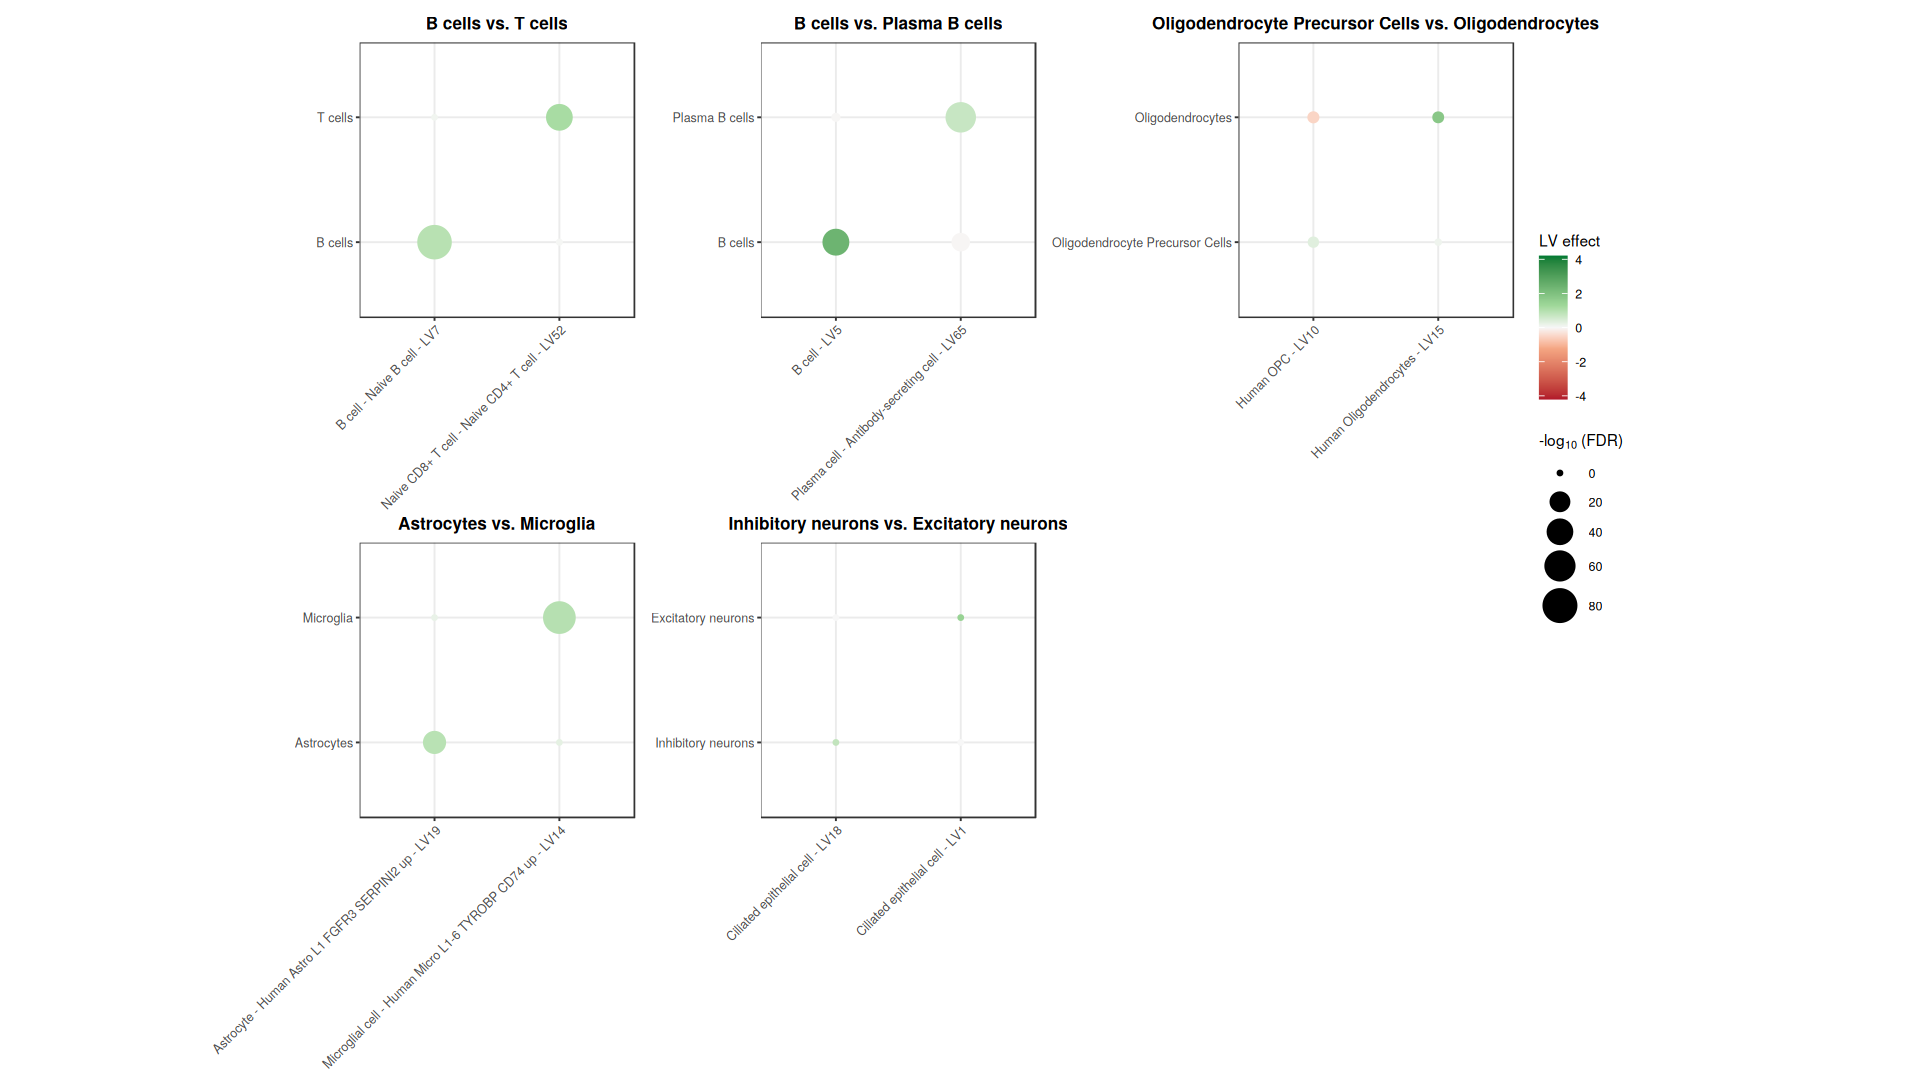

In [3]:
# Zoomed dot-grid (reuses enr_all/Z_LIM/Q_LIM from the main plot above,
# unmodified) restricted to the hardest cases: biologically related cell-type
# subtypes. Most panels compare cells within the same dataset; the final panel
# intentionally compares selected brain LVs across datasets. Cross-dataset cells
# are shown as neutral when they were not part of the dataset-local enrichment
# table.
RELATED_GROUPS <- list(
    list(entries = data.frame(ds = c("PBMC_Perez2022", "PBMC_Perez2022"),
                              ct = c("B_cell", "T_cell"), stringsAsFactors = FALSE)),
    list(entries = data.frame(ds = c("PBMC_1k1k", "PBMC_1k1k"),
                              ct = c("B_cell", "Plasma_B"), stringsAsFactors = FALSE)),
    list(entries = data.frame(ds = c("Brain_Xiong2023", "Brain_Xiong2023"),
                              ct = c("Opc", "Oli"), stringsAsFactors = FALSE)),
    list(entries = data.frame(ds = c("Brain_Mathys2023", "Brain_Mathys2023"),
                              ct = c("Ast", "Mic"), stringsAsFactors = FALSE)),
    list(entries = data.frame(ds = c("Brain_Mathys2023", "Brain_Xiong2023"),
                              ct = c("Inh", "Exc"), stringsAsFactors = FALSE))
)

make_group_dot_panel <- function(grp) {
    entries <- grp$entries
    entries$entry_id <- paste(entries$ds, entries$ct, sep = "__")

    sel <- dplyr::bind_rows(lapply(seq_len(nrow(entries)), function(i) {
        ds  <- entries$ds[i]
        ct  <- entries$ct[i]
        res <- module_results[[ds]]
        if (is.null(res)) return(NULL)
        row <- res$selected[res$selected$cell_type == ct, ]
        if (nrow(row) == 0) return(NULL)
        row <- row[1, , drop = FALSE]
        row$entry_dataset   <- ds
        row$entry_cell_type <- ct
        row$entry_id        <- entries$entry_id[i]
        row
    }))
    if (nrow(sel) < 2) return(NULL)

    row_labels <- setNames(ct_label(entries$ct), entries$entry_id)
    tp_for_sel <- dplyr::bind_rows(lapply(seq_len(nrow(sel)), function(i) {
        tp <- top_pathway_df[top_pathway_df$dataset == sel$entry_dataset[i] &
                             top_pathway_df$cell_type == sel$entry_cell_type[i], ]
        if (nrow(tp) == 0) return(data.frame(
            entry_id = sel$entry_id[i], top_pathway_label = NA_character_,
            recovered = FALSE, top1_fdr = NA_real_, stringsAsFactors = FALSE))
        data.frame(entry_id = sel$entry_id[i], top_pathway_label = tp$top_pathway_label[1],
                   recovered = tp$recovered[1], top1_fdr = tp$top1_fdr[1],
                   stringsAsFactors = FALSE)
    }))
    tp_label <- setNames(tp_for_sel$top_pathway_label, tp_for_sel$entry_id)
    col_labels <- setNames(
        ifelse(is.na(tp_label[sel$entry_id]) | tp_label[sel$entry_id] == sel$LV,
               sel$LV, paste0(tp_label[sel$entry_id], " - ", sel$LV)),
        sel$entry_id)
    recovered_by_entry <- setNames(tp_for_sel$recovered, tp_for_sel$entry_id)
    top1_neg_log10_by_entry <- setNames(-log10(tp_for_sel$top1_fdr + 1e-300),
                                        tp_for_sel$entry_id)

    enr <- dplyr::bind_rows(lapply(seq_len(nrow(sel)), function(i) {
        marker_cts <- entries$ct[entries$ds == sel$entry_dataset[i]]
        sub <- enr_all[enr_all$dataset == sel$entry_dataset[i] &
                       enr_all$LV == sel$LV[i] &
                       enr_all$lv_cell_type == sel$entry_cell_type[i] &
                       enr_all$marker_cell_type %in% marker_cts, ]
        if (nrow(sub) == 0) return(NULL)
        sub$lv_entry_id     <- sel$entry_id[i]
        sub$marker_entry_id <- paste(sub$dataset, sub$marker_cell_type, sep = "__")
        sub
    }))
    if (!all(c("marker_entry_id", "lv_entry_id") %in% names(enr))) {
        enr <- data.frame(marker_entry_id = character(), lv_entry_id = character(),
                          neg_log10_fdr = numeric(), row_effect = numeric(),
                          stringsAsFactors = FALSE)
    }

    grid <- expand.grid(marker_entry_id = entries$entry_id,
                        lv_entry_id = sel$entry_id,
                        stringsAsFactors = FALSE)
    enr <- merge(grid, enr, by = c("marker_entry_id", "lv_entry_id"), all.x = TRUE)
    enr$neg_log10_fdr[is.na(enr$neg_log10_fdr)] <- 0

    effect_lookup <- dplyr::bind_rows(lapply(seq_len(nrow(sel)), function(i) {
        marker_entries <- entries[entries$ds == sel$entry_dataset[i], ]
        eff <- lv_effect_all[lv_effect_all$dataset == sel$entry_dataset[i] &
                             lv_effect_all$LV == sel$LV[i] &
                             lv_effect_all$marker_cell_type %in% marker_entries$ct, ]
        if (nrow(eff) == 0) return(NULL)
        eff$lv_entry_id     <- sel$entry_id[i]
        eff$marker_entry_id <- paste(eff$dataset, eff$marker_cell_type, sep = "__")
        eff[, c("marker_entry_id", "lv_entry_id", "row_effect")]
    }))
    enr$row_effect <- NULL
    if (nrow(effect_lookup) > 0)
        enr <- merge(enr, effect_lookup, by = c("marker_entry_id", "lv_entry_id"), all.x = TRUE)
    if (!"row_effect" %in% names(enr)) enr$row_effect <- NA_real_
    enr$row_effect[is.na(enr$row_effect)] <- 0

    recover_idx <- enr$marker_entry_id == enr$lv_entry_id &
                   recovered_by_entry[enr$lv_entry_id] %in% TRUE &
                   !is.na(top1_neg_log10_by_entry[enr$lv_entry_id])
    enr$neg_log10_fdr[recover_idx] <- pmax(enr$neg_log10_fdr[recover_idx],
                                           top1_neg_log10_by_entry[enr$lv_entry_id[recover_idx]])
    enr$marker_row_label <- factor(row_labels[enr$marker_entry_id], levels = unname(row_labels))
    enr$lv_col_label     <- factor(col_labels[enr$lv_entry_id], levels = unname(col_labels))

    ggplot(enr, aes(x = lv_col_label, y = marker_row_label)) +
        geom_point(aes(size = neg_log10_fdr, color = row_effect)) +
        scale_size_continuous(limits = c(0, Q_LIM), range = c(1, 9),
                              name = expression("-" * log[10] ~ "(FDR)")) +
        scale_color_gradientn(colors = c("#b2182b", "#f4a582", "#f7f7f7", "#a1d99b", "#007a33"),
                              values = c(0, 0.35, 0.5, 0.65, 1),
                              limits = c(-Z_LIM, Z_LIM),
                              name = "LV effect") +
        coord_fixed() +
        theme_bw(base_size = 9) +
        theme(axis.text.x = element_text(angle = 45, hjust = 1),
              plot.title  = element_text(face = "bold", size = 10, hjust = 0.5)) +
        labs(x = NULL, y = NULL, title = paste(unname(row_labels), collapse = " vs. "))
}

group_dot_panels <- Filter(Negate(is.null), lapply(RELATED_GROUPS, make_group_dot_panel))

options(repr.plot.width = 16, repr.plot.height = 9)
p_group_dots <- wrap_plots(group_dot_panels, ncol = 3, guides = "collect") &
    theme(legend.position = "right")
print(p_group_dots)


## Export canonical hard-cell results

In [4]:
hard_entries <- dplyr::bind_rows(lapply(seq_along(RELATED_GROUPS), function(i) {
  entries <- RELATED_GROUPS[[i]]$entries
  entries$group_id <- i
  entries
}))

hard_table <- hard_entries %>%
  left_join(top_lvs_df, by = c('ds' = 'dataset', 'ct' = 'cell_type')) %>%
  left_join(recovery_df, by = c('ds' = 'dataset', 'ct' = 'cell_type'),
            suffix = c('_specificity', '_singlecell'))

hard_corr_long <- dplyr::bind_rows(lapply(seq_len(nrow(hard_entries)), function(i) {
  entry <- hard_entries[i, ]
  assigned <- top_lvs_df[top_lvs_df$dataset == entry$ds & top_lvs_df$cell_type == entry$ct, ]
  if (!nrow(assigned)) return(NULL)
  candidates <- hard_entries$ct[hard_entries$ds == entry$ds]
  out <- lv_corr_full[lv_corr_full$dataset == entry$ds &
                      lv_corr_full$LV == assigned$LV[1] &
                      lv_corr_full$cell_type %in% candidates, ]
  if (!nrow(out)) return(NULL)
  out$assigned_cell_type <- entry$ct
  out$group_id <- entry$group_id
  out
}))

hard_enrichment_long <- dplyr::bind_rows(lapply(seq_len(nrow(hard_entries)), function(i) {
  entry <- hard_entries[i, ]
  assigned <- top_lvs_df[top_lvs_df$dataset == entry$ds & top_lvs_df$cell_type == entry$ct, ]
  if (!nrow(assigned)) return(NULL)
  candidates <- hard_entries$ct[hard_entries$ds == entry$ds]
  out <- enr_all[enr_all$dataset == entry$ds & enr_all$LV %in% assigned$LV &
                 enr_all$marker_cell_type %in% candidates, ]
  if (!nrow(out)) return(NULL)
  out$group_id <- entry$group_id
  out
}))

write.csv(hard_table, file.path(OUT_DIR, 'hard_cell_types.csv'), row.names = FALSE)
write.csv(hard_corr_long, file.path(OUT_DIR, 'related_lv_correlations.csv'), row.names = FALSE)
write.csv(hard_enrichment_long, file.path(OUT_DIR, 'hard_marker_enrichment.csv'), row.names = FALSE)
ggsave(file.path(OUT_DIR, 'related_lv_correlation_heatmaps.png'), p_groups,
       width = 16, height = 9, dpi = 150)
ggsave(file.path(OUT_DIR, 'hard_cell_marker_enrichment.png'), p_group_dots,
       width = 16, height = 9, dpi = 150)
hard_table

# Machine-readable comparison with the archived pre-fresh-run results.
# LV numbers are deliberately not compared: correlations and subspaces are
# identifiable, while individual LV labels are not.
HIST_BIO <- here('output', '03_model_biology', 'tmp_pseudobulk')
HIST_DATA <- here('data', 'pseudobulk')
PROD_ROOT <- here('output', '01_model_building', '00_pseudobulk')

compare_metric <- function(fresh_path, historic_path, keys, fresh_value, historic_value, scope, expected_change = FALSE) {
  if (!file.exists(fresh_path) || !file.exists(historic_path)) return(data.frame(scope = scope, status = 'requires_investigation', n_common = 0L, statistic = NA_real_, detail = 'reference unavailable'))
  fresh <- read.csv(fresh_path, stringsAsFactors = FALSE)
  historic <- read.csv(historic_path, stringsAsFactors = FALSE)
  keys <- intersect(keys, intersect(names(fresh), names(historic)))
  if (!length(keys) || !fresh_value %in% names(fresh) || !historic_value %in% names(historic)) return(data.frame(scope = scope, status = 'requires_investigation', n_common = 0L, statistic = NA_real_, detail = 'incompatible columns'))
  fresh$.value_fresh <- fresh[[fresh_value]]; historic$.value_historic <- historic[[historic_value]]
  x <- merge(fresh[, c(keys, '.value_fresh')], historic[, c(keys, '.value_historic')], by = keys)
  x <- x[is.finite(x$.value_fresh) & is.finite(x$.value_historic), , drop = FALSE]
  if (nrow(x) < 2L) return(data.frame(scope = scope, status = 'requires_investigation', n_common = nrow(x), statistic = NA_real_, detail = 'fewer than two common finite values'))
  r <- suppressWarnings(cor(x$.value_fresh, x$.value_historic))
  status <- if (is.finite(r) && r >= 0.99) 'matched' else if (expected_change) 'expected_change' else 'requires_investigation'
  data.frame(scope = scope, status = status, n_common = nrow(x), statistic = r, detail = sprintf('Pearson r of %s', fresh_value))
}

comparison_rows <- list()
datasets <- c('Brain_Mathys2023', 'Brain_Xiong2023', 'Heart_Datar2026', 'PBMC_1k1k', 'PBMC_Perez2022', 'Lung_Sikkema2023')
for (ds in datasets) {
  fresh_dir <- file.path(PROD_ROOT, ds, 'pseudobulk')
  hist_dir <- file.path(HIST_DATA, ds)
  fresh_bulk <- read.csv(file.path(fresh_dir, 'bulk_expr.csv'), row.names = 1, check.names = FALSE)
  hist_bulk <- read.csv(file.path(hist_dir, 'bulk_expr.csv'), row.names = 1, check.names = FALSE)
  common_samples <- intersect(colnames(fresh_bulk), colnames(hist_bulk))
  common_genes <- intersect(rownames(fresh_bulk), rownames(hist_bulk))
  sample_status <- if (setequal(colnames(fresh_bulk), colnames(hist_bulk))) 'matched' else 'expected_change'
  comparison_rows[[length(comparison_rows) + 1L]] <- data.frame(scope = paste0('pseudobulk_samples:', ds), status = sample_status, n_common = length(common_samples), statistic = NA_real_, detail = sprintf('%d fresh; %d historical', ncol(fresh_bulk), ncol(hist_bulk)))
  if (length(common_samples) && length(common_genes)) {
    r_expr <- cor(as.numeric(as.matrix(fresh_bulk[common_genes, common_samples])), as.numeric(as.matrix(hist_bulk[common_genes, common_samples])))
    comparison_rows[[length(comparison_rows) + 1L]] <- data.frame(scope = paste0('pseudobulk_expression:', ds), status = if (r_expr >= 0.99) 'matched' else 'expected_change', n_common = length(common_samples) * length(common_genes), statistic = r_expr, detail = 'common-gene/sample expression Pearson r')
  }
  fresh_truth <- read.csv(file.path(fresh_dir, 'truthFrac_v0.csv'), row.names = 1, check.names = FALSE)
  hist_truth <- read.csv(file.path(hist_dir, 'truthFrac_v0.csv'), row.names = 1, check.names = FALSE)
  ct <- intersect(rownames(fresh_truth), rownames(hist_truth)); smp <- intersect(colnames(fresh_truth), colnames(hist_truth))
  if (length(ct) && length(smp)) {
    r_truth <- cor(as.numeric(as.matrix(fresh_truth[ct, smp])), as.numeric(as.matrix(hist_truth[ct, smp])))
    comparison_rows[[length(comparison_rows) + 1L]] <- data.frame(scope = paste0('truth_fractions:', ds), status = if (r_truth >= 0.999) 'matched' else 'expected_change', n_common = length(ct) * length(smp), statistic = r_truth, detail = 'common-cell-type/sample truth Pearson r')
  }
}
# CLAMPfull subspaces are compared by principal angles, not raw LV labels.
for (ds in datasets) {
  fresh_z <- read.csv(file.path(PROD_ROOT, ds, 'models', 'CLAMPfull', 'Z.csv'), row.names = 1, check.names = FALSE)
  historic_z <- read.csv(here('output', '01_model_building', '05_pseudobulk', ds, 'CLAMPfull', 'Z.csv'), row.names = 1, check.names = FALSE)
  genes <- intersect(rownames(fresh_z), rownames(historic_z))
  q_fresh <- qr.Q(qr(as.matrix(fresh_z[genes, , drop = FALSE])))
  q_historic <- qr.Q(qr(as.matrix(historic_z[genes, , drop = FALSE])))
  principal_cosines <- svd(crossprod(q_fresh, q_historic), nu = 0, nv = 0)$d
  similarity <- mean(principal_cosines^2)
  comparison_rows[[length(comparison_rows) + 1L]] <- data.frame(scope = paste0('CLAMPfull_subspace:', ds), status = if (similarity >= 0.99) 'matched' else 'expected_change', n_common = length(genes), statistic = similarity, detail = 'mean squared canonical correlation of Z subspaces')
}
comparison_rows[[length(comparison_rows) + 1L]] <- compare_metric(file.path(BENCH_DIR, 'benchmark_long.csv'), file.path(HIST_BIO, '00_benchmark', 'benchmark_long.csv'), c('dataset', 'method', 'truth', 'cell_type'), 'cor', 'cor', 'model_LV_celltype_correlations', TRUE)
comparison_rows[[length(comparison_rows) + 1L]] <- compare_metric(file.path(ROOT_OUT, '01_holdout80', 'heldout_metrics.csv'), file.path(HIST_BIO, '01_holdout80', 'heldout_metrics.csv'), c('dataset', 'cell_type'), 'heldout_cor', 'test_pearson', 'holdout_correlations', TRUE)
comparison_rows[[length(comparison_rows) + 1L]] <- compare_metric(file.path(DIS_DIR, 'lv_specificity_margins.csv'), file.path(HIST_BIO, '01_disentangle', 'lv_specificity_margins.csv'), c('dataset', 'cell_type'), 'margin_ct', 'margin_ct', 'disentanglement_margins', TRUE)
comparison_rows[[length(comparison_rows) + 1L]] <- compare_metric(file.path(SC_DIR, 'recovery_summary.csv'), file.path(HIST_BIO, '03_b_matrix_singlecell', 'recovery_summary.csv'), c('dataset', 'cell_type'), 'recovery_pct', 'recovery_pct', 'single_cell_recovery', TRUE)
comparison_rows[[length(comparison_rows) + 1L]] <- compare_metric(file.path(OUT_DIR, 'hard_cell_types.csv'), file.path(HIST_BIO, '04_hard_cell_types', 'hard_cell_types.csv'), c('ds', 'ct'), 'margin_ct', 'margin_ct', 'hard_cell_type_margins', TRUE)
historical_comparison <- dplyr::bind_rows(comparison_rows)
write.csv(historical_comparison, file.path(OUT_DIR, 'historical_comparison.csv'), row.names = FALSE)
historical_comparison


ds,ct,group_id,LV,cor,r_next_best_ct,r_next_best_lv,margin_ct,margin_lv,n_top,⋯,diag_count,recovery_pct,assigned_lv,assignment_cor,n_true_cells,n_population,prevalence,max_achievable_purity,purity_ratio,purity_lift
<chr>,<chr>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,⋯,<int>,<dbl>,<chr>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
PBMC_Perez2022,B_cell,1,LV7,0.9353468,0.6937771,-0.10289443,0.24156973,1.0382412,12637,⋯,12624,99.897127,LV7,0.9353468,152981,1263676,0.121060303,1.0000000,0.99897127,8.2518484
PBMC_Perez2022,T_cell,1,LV52,0.7310498,0.4953315,0.03466742,0.23571837,0.6963824,12637,⋯,12409,98.195774,LV52,0.7310498,637669,1263676,0.504614316,1.0000000,0.98195774,1.9459570
PBMC_1k1k,B_cell,2,LV37,0.7669833,0.7459676,-0.01178259,0.02101576,0.7787659,12490,⋯,12015,96.196958,LV37,0.7669833,125825,1248980,0.100742206,1.0000000,0.96196958,9.5488238
PBMC_1k1k,Plasma_B,2,LV65,0.7131151,0.3569448,0.31062636,0.35617029,0.4024887,12490,⋯,3754,30.056045,LV65,0.7131151,3754,1248980,0.003005653,0.3005604,1.00000000,99.9983987
Brain_Xiong2023,Opc,3,LV10,0.3392707,0.4213534,0.23409840,-0.08208276,0.1051723,4150,⋯,1198,28.867470,LV10,0.3392707,19272,414964,0.046442583,1.0000000,0.28867470,6.2157331
Brain_Xiong2023,Oli,3,LV15,0.9036064,0.7496917,0.52258893,0.15391473,0.3810175,4150,⋯,4059,97.807229,LV15,0.9036064,119456,414964,0.287870755,1.0000000,0.97807229,3.3976091
Brain_Mathys2023,Ast,4,LV19,0.9124094,0.3212691,0.59867534,0.59114029,0.3137341,23278,⋯,17472,75.057995,LV19,0.9124094,148201,2327742,0.063667279,1.0000000,0.75057995,11.7891004
Brain_Mathys2023,Mic,4,LV14,0.9607457,0.4319029,0.32399944,0.52884275,0.6367462,23278,⋯,23278,100.000000,LV14,0.9607457,76310,2327742,0.032782843,1.0000000,1.00000000,30.5037610
Brain_Mathys2023,Inh,5,LV18,0.7945048,0.7004030,0.61327807,0.09410182,0.1812268,23278,⋯,988,4.244351,LV18,0.7945048,329379,2327742,0.141501507,1.0000000,0.04244351,0.2999509


scope,status,n_common,statistic,detail
<chr>,<chr>,<int>,<dbl>,<chr>
pseudobulk_samples:Brain_Mathys2023,matched,80,NA,80 fresh; 80 historical
pseudobulk_expression:Brain_Mathys2023,matched,1370800,0.9978042,common-gene/sample expression Pearson r
truth_fractions:Brain_Mathys2023,expected_change,560,0.9901409,common-cell-type/sample truth Pearson r
pseudobulk_samples:Brain_Xiong2023,matched,74,NA,74 fresh; 74 historical
pseudobulk_expression:Brain_Xiong2023,matched,1919856,0.9987119,common-gene/sample expression Pearson r
truth_fractions:Brain_Xiong2023,expected_change,518,0.9806501,common-cell-type/sample truth Pearson r
pseudobulk_samples:Heart_Datar2026,matched,209,NA,209 fresh; 209 historical
pseudobulk_expression:Heart_Datar2026,matched,7649609,1.0000000,common-gene/sample expression Pearson r
truth_fractions:Heart_Datar2026,matched,2926,1.0000000,common-cell-type/sample truth Pearson r
